### Import python libararies for EDA

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from matplotlib.ticker import MaxNLocator

In [11]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows

### Import the consolidated data into a dataframe for EDA and Cleaning

In [33]:
##filepath = '/Users/ananddivakaran/Documents/Anand/MDS/cpsa/data/raw/neiss_combined_raw_untouched_data.csv'
filepath = '../data/raw/neiss_combined_raw_untouched_data.csv'

data_original = pd.read_csv(filepath, engine='pyarrow')

In [34]:
# Deep copy to preserve original data
data = data_original.copy()

In [35]:
data.shape

(7315732, 26)

The data has 7 Million observations and 26 features

In [36]:
data.describe()

,data_year,CPSC_Case_Number,Age,Sex,Race,Hispanic,Body_Part,Diagnosis,Body_Part_2,Diagnosis_2,Disposition,Location,Fire_Involvement,Product_1,Product_2,Product_3,Alcohol,Drug,PSU,Weight
count,7.315732e+06,7.315732e+06,7.315732e+06,7.315732e+06,7.315732e+06,2.031804e+06,7.315732e+06,7.315732e+06,449039.000000,449039.000000,7.315732e+06,7.315732e+06,7.315732e+06,7.315732e+06,7.315732e+06,7.315732e+06,2.031804e+06,2.031804e+06,7.315732e+06,7.315732e+06
mean,2.014283e+03,1.438899e+08,4.379820e+01,1.450022e+00,1.034293e+00,1.317193e+00,6.471971e+01,6.018758e+01,65.485708,61.034841,1.335680e+00,2.432491e+00,9.460844e-03,2.126031e+03,2.585908e+02,9.413754e+00,1.905007e-02,2.217143e-02,4.540746e+01,3.713500e+01
std,5.697235e+00,5.709018e+07,4.986483e+01,4.977646e-01,9.262696e-01,8.911552e-01,2.401576e+01,6.210480e+00,22.699428,7.163684,1.030898e+00,3.196199e+00,1.531823e-01,1.352375e+03,7.684433e+02,1.504334e+02,1.367010e-01,1.472409e-01,2.953424e+01,2.995122e+01
min,2.005000e+03,5.010034e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.100000e+01,0.000000,41.000000,1.000000e+00,0.000000e+00,0.000000e+00,1.020000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,4.505600e+00
25%,2.009000e+03,9.121282e+07,1.200000e+01,1.000000e+00,0.000000e+00,0.000000e+00,3.600000e+01,5.700000e+01,35.000000,53.000000,1.000000e+00,0.000000e+00,0.000000e+00,1.211000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.100000e+01,1.485370e+01
50%,2.014000e+03,1.408530e+08,2.800000e+01,1.000000e+00,1.000000e+00,2.000000e+00,7.500000e+01,5.900000e+01,76.000000,59.000000,1.000000e+00,1.000000e+00,0.000000e+00,1.807000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.100000e+01,1.684130e+01
75%,2.019000e+03,1.908346e+08,5.800000e+01,2.000000e+00,1.000000e+00,2.000000e+00,8.200000e+01,6.400000e+01,82.000000,68.000000,1.000000e+00,4.000000e+00,0.000000e+00,3.272000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.700000e+01,6.903390e+01
max,2.024000e+03,2.503063e+08,2.230000e+02,2.000000e+00,6.000000e+00,2.000000e+00,9.400000e+01,7.400000e+01,94.000000,74.000000,9.000000e+00,9.000000e+00,3.000000e+00,5.555000e+03,5.555000e+03,5.555000e+03,1.000000e+00,1.000000e+00,2.070000e+02,1.121671e+02


In [15]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7315732 entries, 0 to 7315731
Data columns (total 26 columns):
 #   Column             Dtype  
---  ------             -----  
 0   data_year          int64  
 1   CPSC_Case_Number   int64  
 2   Treatment_Date     object 
 3   Age                int64  
 4   Sex                int64  
 5   Race               int64  
 6   Other_Race         str    
 7   Hispanic           float64
 8   Body_Part          int64  
 9   Diagnosis          int64  
 10  Other_Diagnosis    str    
 11  Body_Part_2        float64
 12  Diagnosis_2        float64
 13  Other_Diagnosis_2  str    
 14  Disposition        int64  
 15  Location           int64  
 16  Fire_Involvement   int64  
 17  Product_1          int64  
 18  Product_2          int64  
 19  Product_3          int64  
 20  Alcohol            float64
 21  Drug               float64
 22  Narrative_1        str    
 23  Stratum            str    
 24  PSU                int64  
 25  Weight             float64
dt

####  We need to understand the data in the raw file before performing feature engineering 


### Count of injury data by year

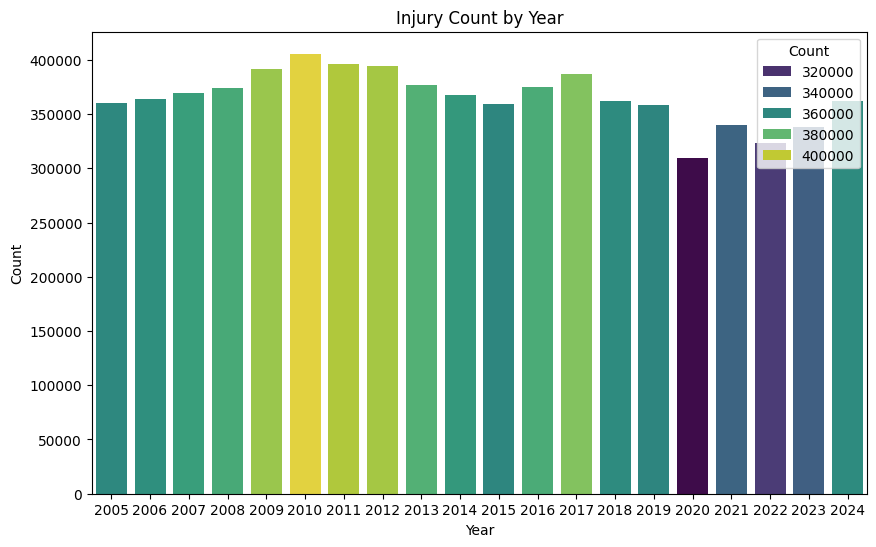

In [37]:
#data['data_year'] = pd.to_datetime(data['data_year'].astype(str), format='%Y')
injury_count_by_year = data.data_year.value_counts(ascending = False).reset_index()
injury_count_by_year.columns = ['Year', 'Count']
injury_count_by_year.sort_values(by='Year', ascending=True, inplace=True)
plt.figure(figsize=(10,6))
sns.barplot(y='Count',x='Year', data=injury_count_by_year, hue='Count', dodge=False, palette='viridis')
plt.title('Injury Count by Year')
plt.show()

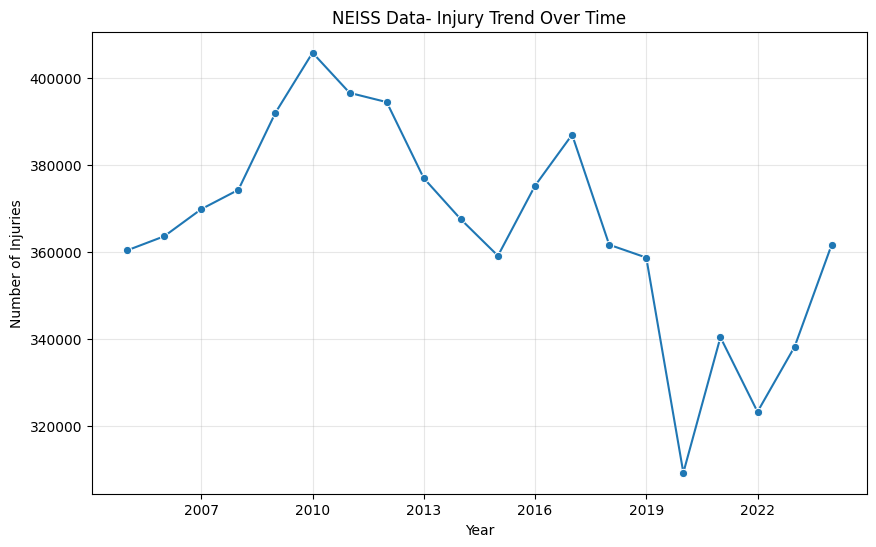

In [47]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=injury_count_by_year, x='Year', y='Count', marker='o')
# Force the x-axis to only show integers (prevents "2015.5" labels)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('NEISS Data- Injury Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Injuries')
plt.grid(True, alpha=0.3) # Add a light grid for readability
plt.show()

#### Observations
1. The raw data in the file is kind of modelratly balanced when grouped at year level. <br>
2. There is dip in the injury information between 2019 and and 2022 - may be due to the COVID-19 pandemic and people staying at home - thereby reducing the number of overall injuries.

### Univariate analysis of Injury data by age

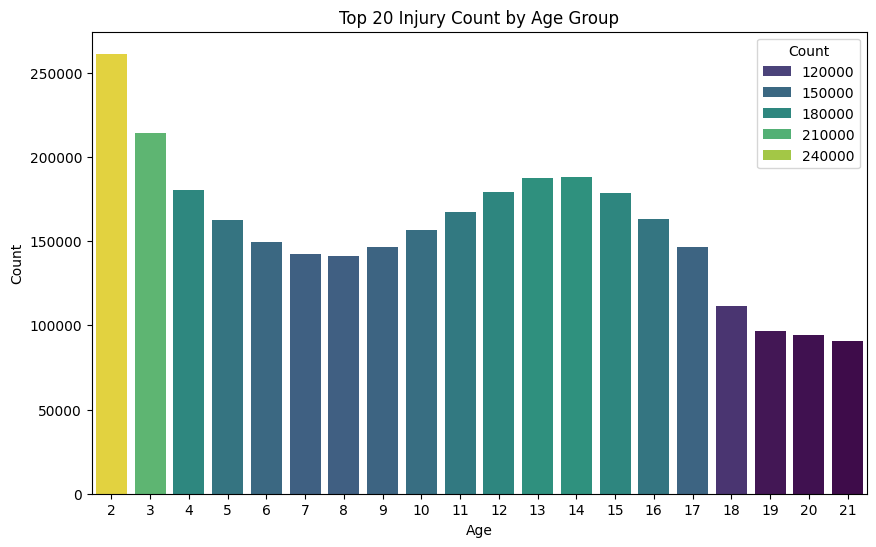

In [17]:
top20_injury_count_by_age = data.Age.value_counts().sort_values(ascending=False).reset_index().head(20)
top20_injury_count_by_age.columns = ['Age', 'Count']
plt.figure(figsize=(10,6))
sns.barplot(y='Count',x='Age', data=top20_injury_count_by_age , hue='Count', dodge=False, palette='viridis')
plt.title('Top 20 Injury Count by Age Group')
plt.show()

#### Observations:
1. Maximum number of injuries seems to  observed for the age 2 <br>
2. After age 18, the number of injuries seems to stabilize 

### Injury data by Sex

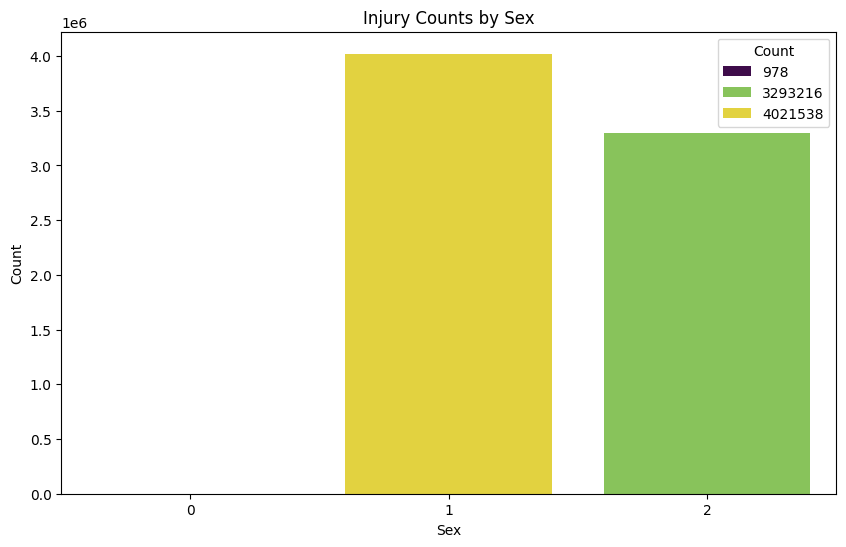

In [18]:
top20_injury_count_by_sex = data.Sex.value_counts().sort_values(ascending=False).reset_index().head(20)
top20_injury_count_by_sex.columns = ['Sex', 'Count']
plt.figure(figsize=(10,6))
sns.barplot(y='Count',x='Sex', data=top20_injury_count_by_sex , hue='Count', dodge=False, palette='viridis')
plt.title('Injury Counts by Sex')
plt.show()

### Injury data by Race

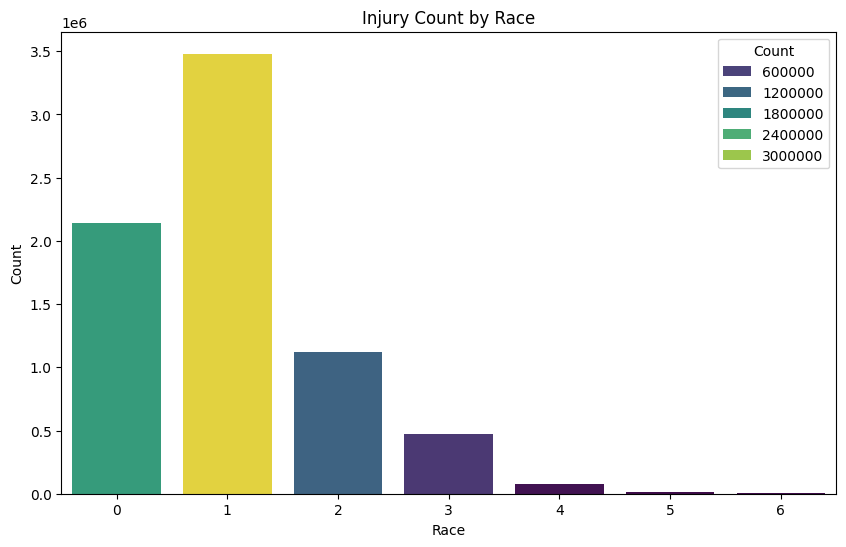

In [19]:
top20_injury_count_by_race = data.Race.value_counts().sort_values(ascending=False).reset_index().head(20)
top20_injury_count_by_race.columns = ['Race', 'Count']
plt.figure(figsize=(10,6))
sns.barplot(y='Count',x='Race', data=top20_injury_count_by_race , hue='Count', dodge=False, palette='viridis')
plt.title('Injury Count by Race')
plt.show()